# ICU Cohort Analysis: Delirium Prediction & Length of Stay
 
This notebook unifies the **Primary Analysis** (Predictive ML Modeling for ICU Delirium) and the **Subsequent Analysis** (Statistical models predicting Length of Stay) into a single analytical pipeline.

### Objectives
1. **Predictive Modeling:** Build tree-based and regularized logistic models to identify baseline physiological drivers of delirium (focusing heavily on language discordance).
2. **LOS Modeling:** Assess the operational impact (Length of Stay) via Log-linear OLS, Negative Binomial, and Quantile (Median) regression models.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, roc_curve, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid', context='talk')

## 1. Data Loading & Feature Engineering

In [13]:
# 1. Load Data
df = pd.read_csv('icu_cohort_complete.csv')
print(f"Original shape: {df.shape}")

# 2. Study Population and Exclusions
print("\n--- Applying Exclusions ---")
df = df.sort_values(by=['patient_id', 'admission_dttm']).drop_duplicates(subset=['patient_id'], keep='first')
print(f"Shape after keeping first admission: {df.shape}")

df = df[~df['location_type'].isin(['neuro_icu', 'mixed_neuro_icu'])]
print(f"Shape after excluding neuro ICUs: {df.shape}")

df['cam_total_assessments'] = (df['cam_mental_yes_count'] + df['cam_mental_no_count'] + df['cam_mental_unable_count'] +
                               df['cam_loc_yes_count'] + df['cam_loc_no_count'] + 
                               df['cam_thinking_yes_count'] + df['cam_thinking_no_count'] + df['cam_thinking_unable_count'] + 
                               df['cam_inattention_yes_count'] + df['cam_inattention_no_count'] + df['cam_inattention_unable_count'])

df = df[df['cam_total_assessments'] > 0]
print(f"Shape after removing cases with no CAM assessments: {df.shape}")

# Outcome Definition
df['delirium_any'] = np.where(df['cam_total_positive_count'] > 0, 1, 0)
print(f"Overall Delirium incidence: {df['delirium_any'].mean():.2%}")

# 3. Define Predictor and Features
num_features = ['age_at_admission', 'sodium_min', 'sodium_max', 'creatinine_max', 'rass_min', 'rass_max', 'rass_median']
cat_features = ['sex_category', 'race_category', 'ethnicity_category', 'location_type']
predictor = 'is_english'

# Feature Engineering (V2 Logic)
print("\n--- Feature Engineering (V2 Logic) ---")
# Vasoactive Flag
for col in ['med_norepinephrine', 'med_epinephrine', 'med_phenylephrine', 'med_vasopressin']:
    if col not in df.columns: df[col] = 0
    df[col] = df[col].fillna(0)
df['vasoactive_flag'] = np.where((df['med_norepinephrine'] > 0) | (df['med_epinephrine'] > 0) | 
                                 (df['med_phenylephrine'] > 0) | (df['med_vasopressin'] > 0), 1, 0)

# Dementia Flag
for col in ['hx_dementia', 'hx_alzheimers']:
    if col not in df.columns: df[col] = 0
    df[col] = df[col].fillna(0)
df['dementia_flag'] = np.where((df['hx_dementia'] == 1) | (df['hx_alzheimers'] == 1), 1, 0)

# Drug Use Disorder Flag
drug_cols = ['hx_alcohol_disorder', 'hx_opioid_disorder', 'hx_cannabis_disorder', 'hx_sedative_disorder', 
             'hx_cocaine_disorder', 'hx_stimulant_disorder', 'hx_hallucinogen_disorder']
for col in drug_cols:
    if col not in df.columns: df[col] = 0
    df[col] = df[col].fillna(0)
df['drug_use_disorder_flag'] = np.where((df['hx_alcohol_disorder'] == 1) | (df['hx_opioid_disorder'] == 1) | 
                                        (df['hx_cannabis_disorder'] == 1) | (df['hx_sedative_disorder'] == 1) | 
                                        (df['hx_cocaine_disorder'] == 1) | (df['hx_stimulant_disorder'] == 1) | 
                                        (df['hx_hallucinogen_disorder'] == 1), 1, 0)

# Explicit conditions
other_clinical = ['hx_deaf', 'hx_blind', 'hx_stroke', 'hx_schizophrenia']
for col in other_clinical:
    if col not in df.columns: df[col] = 0
    df[col] = df[col].fillna(0)

binary_features = ['vasoactive_flag', 'dementia_flag', 'drug_use_disorder_flag'] + other_clinical

# Compile final dataset
cat_features_for_model = cat_features + [predictor]
selected_cols = num_features + cat_features_for_model + binary_features + ['delirium_any']
df_final = df[selected_cols].copy()

Original shape: (47048, 78)

--- Applying Exclusions ---
Shape after keeping first admission: (33732, 78)
Shape after excluding neuro ICUs: (32112, 78)
Shape after removing cases with no CAM assessments: (23947, 79)
Overall Delirium incidence: 44.51%

--- Feature Engineering (V2 Logic) ---


## 2. Baseline Characteristics (Table 1)

In [14]:
demographic_cols = ['age_at_admission', 'sex_category', 'race_category', 'ethnicity_category']
all_table_vars = num_features + cat_features + binary_features
clinical_cols = [c for c in all_table_vars if c not in demographic_cols and c != predictor]

def create_table_1(data, predictor_col, demographic_cols, clinical_cols):
    results = []
    total_n = len(data)
    conc_data = data[data[predictor_col] == 1]
    disc_data = data[data[predictor_col] == 0]
    conc_n = len(conc_data)
    disc_n = len(disc_data)
    
    def calc_smd(g1, g0):
        v1, v0 = g1.var(), g0.var()
        m1, m0 = g1.mean(), g0.mean()
        pooled_sd = np.sqrt((v1 + v0) / 2)
        if pooled_sd == 0 or np.isnan(pooled_sd): return 0.0
        return np.abs(m1 - m0) / pooled_sd

    def process_var(var):
        is_num = pd.api.types.is_numeric_dtype(data[var]) and data[var].nunique() > 2
        var_clean = var.replace('_', ' ').capitalize()
        
        if is_num:
            dropped = data[var].dropna()
            g1 = conc_data[var].dropna()
            g0 = disc_data[var].dropna()
            
            smd = calc_smd(g1, g0)
            
            stat, p_norm = stats.normaltest(dropped)
            is_normal = p_norm > 0.05
            
            if is_normal:
                test_name = "t-test"
                var_label = f"  {var_clean} [Mean ± SD]"
                total_val = f"{dropped.mean():.2f} ± {dropped.std():.2f}"
                conc_val = f"{g1.mean():.2f} ± {g1.std():.2f}"
                disc_val = f"{g0.mean():.2f} ± {g0.std():.2f}"
            else:
                u_stat, p_val = stats.mannwhitneyu(g1, g0, alternative='two-sided')
                test_name = "Mann-Whitney U"
                var_label = f"  {var_clean} [Median (IQR)]"
                total_val = f"{dropped.median():.2f} ({dropped.quantile(0.25):.2f}-{dropped.quantile(0.75):.2f})"
                conc_val = f"{g1.median():.2f} ({g1.quantile(0.25):.2f}-{g1.quantile(0.75):.2f})"
                disc_val = f"{g0.median():.2f} ({g0.quantile(0.25):.2f}-{g0.quantile(0.75):.2f})"
                p_val_str = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
            
            if is_normal:
                t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)
                p_val_str = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
                
            results.append({
                'Variables': var_label,
                f'Total (N={total_n})': total_val,
                f'Language Concordant (N={conc_n})': conc_val,
                f'Language Discordant (N={disc_n})': disc_val,
                'SMD': f"{smd:.3f}",
                'p-value': p_val_str,
                'Test Used': test_name
            })
            
        else:
            contingency = pd.crosstab(data[var], data[predictor_col])
            try:
                chi2, p_val, dof, ex = stats.chi2_contingency(contingency)
                test_name = "Chi-square"
                p_val_str = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
            except:
                p_val_str = "NaN"
                test_name = "Failed"
                
            is_binary = (data[var].nunique() <= 2)
            
            if is_binary:
                val_1 = data[var].dropna().max()
                cnt_tot = (data[var] == val_1).sum()
                perc_tot = (cnt_tot / total_n) * 100
                cnt_c = (conc_data[var] == val_1).sum()
                perc_c = (cnt_c / conc_n) * 100
                cnt_d = (disc_data[var] == val_1).sum()
                perc_d = (cnt_d / disc_n) * 100
                
                p1, p0 = cnt_c / conc_n, cnt_d / disc_n
                var1, var0 = p1*(1-p1), p0*(1-p0)
                pooled_sd = np.sqrt((var1 + var0) / 2)
                smd = np.abs(p1 - p0) / pooled_sd if pooled_sd > 0 else 0.0
                
                results.append({
                    'Variables': f"  {var_clean} (n, %)",
                    f'Total (N={total_n})': f"{int(cnt_tot)} ({perc_tot:.1f}%)",
                    f'Language Concordant (N={conc_n})': f"{int(cnt_c)} ({perc_c:.1f}%)",
                    f'Language Discordant (N={disc_n})': f"{int(cnt_d)} ({perc_d:.1f}%)",
                    'SMD': f"{smd:.3f}",
                    'p-value': p_val_str,
                    'Test Used': test_name
                })
            else:
                results.append({
                    'Variables': f"  {var_clean} (n, %)",
                    f'Total (N={total_n})': "-",
                    f'Language Concordant (N={conc_n})': "-",
                    f'Language Discordant (N={disc_n})': "-",
                    'SMD': "-",
                    'p-value': p_val_str,
                    'Test Used': test_name
                })
                for val in data[var].dropna().unique():
                    cnt_tot = (data[var] == val).sum()
                    perc_tot = (cnt_tot / total_n) * 100
                    cnt_c = (conc_data[var] == val).sum()
                    perc_c = (cnt_c / conc_n) * 100
                    cnt_d = (disc_data[var] == val).sum()
                    perc_d = (cnt_d / disc_n) * 100
                    
                    p1, p0 = cnt_c / conc_n, cnt_d / disc_n
                    var1, var0 = p1*(1-p1), p0*(1-p0)
                    pooled_sd = np.sqrt((var1 + var0) / 2)
                    smd = np.abs(p1 - p0) / pooled_sd if pooled_sd > 0 else 0.0
                    
                    results.append({
                        'Variables': f"    - {val}",
                        f'Total (N={total_n})': f"{int(cnt_tot)} ({perc_tot:.1f}%)",
                        f'Language Concordant (N={conc_n})': f"{int(cnt_c)} ({perc_c:.1f}%)",
                        f'Language Discordant (N={disc_n})': f"{int(cnt_d)} ({perc_d:.1f}%)",
                        'SMD': f"{smd:.3f}",
                        'p-value': "",
                        'Test Used': ""
                    })
    for var in demographic_cols:
        process_var(var)
    for var in clinical_cols:
        process_var(var)
    return pd.DataFrame(results)

table1_df = create_table_1(df_final, predictor, demographic_cols, clinical_cols)
table1_df.style.set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])

,Variables,Total (N=23947),Language Concordant (N=21612),Language Discordant (N=2335),SMD,p-value,Test Used
0,Age at admission [Median (IQR)],68.00 (56.00-78.00),67.00 (56.00-77.00),70.00 (59.00-81.00),0.209,<0.001,Mann-Whitney U
1,"Sex category (n, %)",13725 (57.3%),12398 (57.4%),1327 (56.8%),0.011,0.635,Chi-square
2,"Race category (n, %)",-,-,-,-,<0.001,Chi-square
3,- Black or African American,2330 (9.7%),2059 (9.5%),271 (11.6%),0.068,,
4,- Unknown,3433 (14.3%),3098 (14.3%),335 (14.3%),0.000,,
5,- White,15700 (65.6%),15136 (70.0%),564 (24.2%),1.035,,
6,- Other,1683 (7.0%),927 (4.3%),756 (32.4%),0.779,,
7,- Asian,695 (2.9%),290 (1.3%),405 (17.3%),0.572,,
8,- Native Hawaiian or Other Pacific Islander,39 (0.2%),37 (0.2%),2 (0.1%),0.024,,
9,- American Indian or Alaska Native,67 (0.3%),65 (0.3%),2 (0.1%),0.049,,


## 3. Machine Learning (Primary Analysis)
Build Pipeline, Split Data, GridSearch

In [15]:
X = df_final.drop('delirium_any', axis=1)
y = df_final['delirium_any']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train_val, X_val, y_train_val, y_val = train_test_split(X_train, y_train, test_size=0.176, random_state=42, stratify=y_train)
print(f"Train shape: {X_train_val.shape}")

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])
binary_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value=0))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features_for_model),
        ('bin', binary_transformer, binary_features)
    ])

preprocessor.fit(X_train_val)
X_train_processed = preprocessor.transform(X_train_val)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(cat_encoder.get_feature_names_out(cat_features_for_model))
all_feature_names = num_features + cat_feature_names + binary_features


Train shape: (16771, 19)


### 3.1 Advanced Tuning (L1/L2 Logistic, Random Forest, XGBoost)

In [16]:
param_grid = {'classifier__C': np.logspace(-3, 3, 10)}

pipe_l1 = Pipeline([('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1000, random_state=42))])
gs_l1 = GridSearchCV(pipe_l1, param_grid, cv=5, scoring='roc_auc')
gs_l1.fit(X_train_processed, y_train_val)
print(f"Best L1 parameter C: {gs_l1.best_params_['classifier__C']:.4f}")

rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [10, None], 'min_samples_leaf': [1, 4]}
rf_base = RandomForestClassifier(max_features='sqrt', class_weight='balanced', random_state=42)
gs_rf = GridSearchCV(rf_base, rf_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train_processed, y_train_val)
print(f"Best RF Parameters: {gs_rf.best_params_}")

xgb_param_grid = {'n_estimators': [100], 'learning_rate': [0.1], 'max_depth': [6], 'subsample': [0.8]}
xgb_base = XGBClassifier(scale_pos_weight=(len(y_train_val) - sum(y_train_val)) / sum(y_train_val), random_state=42, eval_metric='logloss')
gs_xgb = GridSearchCV(xgb_base, xgb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
gs_xgb.fit(X_train_processed, y_train_val)
print(f"Best XGB Parameters: {gs_xgb.best_params_}")

# Hyperparameter tuning using validation set

from sklearn.metrics import roc_auc_score

# Logistic Regression

param_grid_l1 = {'C': np.logspace(-3, 3, 10)}

best_score_l1 = 0

best_params_l1 = None

for params in ParameterGrid(param_grid_l1):

    model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1000, random_state=42, **params)

    model.fit(X_train_processed, y_train_val)

    y_pred_proba = model.predict_proba(X_val_processed)[:, 1]

    score = roc_auc_score(y_val, y_pred_proba)

    if score > best_score_l1:

        best_score_l1 = score

        best_params_l1 = params

print(f"Best L1 parameter C: {best_params_l1['C']:.4f}, Validation AUC: {best_score_l1:.4f}")

# Random Forest

rf_param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 4, 10]}

best_score_rf = 0

best_params_rf = None

for params in ParameterGrid(rf_param_grid):

    model = RandomForestClassifier(max_features='sqrt', class_weight='balanced', random_state=42, **params)

    model.fit(X_train_processed, y_train_val)

    y_pred_proba = model.predict_proba(X_val_processed)[:, 1]

    score = roc_auc_score(y_val, y_pred_proba)

    if score > best_score_rf:

        best_score_rf = score

        best_params_rf = params

print(f"Best RF Parameters: {best_params_rf}, Validation AUC: {best_score_rf:.4f}")

# XGBoost

xgb_param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 6, 9], 'subsample': [0.8, 1.0]}

best_score_xgb = 0

best_params_xgb = None

for params in ParameterGrid(xgb_param_grid):

    model = XGBClassifier(scale_pos_weight=(len(y_train_val) - sum(y_train_val)) / sum(y_train_val), random_state=42, eval_metric='logloss', early_stopping_rounds=10, **params)

    model.fit(X_train_processed, y_train_val, eval_set=[(X_val_processed, y_val)], verbose=False)

    y_pred_proba = model.predict_proba(X_val_processed)[:, 1]

    score = roc_auc_score(y_val, y_pred_proba)

    if score > best_score_xgb:

        best_score_xgb = score

        best_params_xgb = params

print(f"Best XGB Parameters: {best_params_xgb}, Validation AUC: {best_score_xgb:.4f}")

# Now, retrain best models on full training data (train + val)

X_train_full_processed = np.vstack([X_train_processed, X_val_processed])

y_train_full = pd.concat([y_train_val, y_val])

best_l1 = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1000, random_state=42, **best_params_l1)

best_l1.fit(X_train_full_processed, y_train_full)

best_rf = RandomForestClassifier(max_features='sqrt', class_weight='balanced', random_state=42, **best_params_rf)

best_rf.fit(X_train_full_processed, y_train_full)

best_xgb = XGBClassifier(scale_pos_weight=(len(y_train_full) - sum(y_train_full)) / sum(y_train_full), random_state=42, eval_metric='logloss', **best_params_xgb)

best_xgb.fit(X_train_full_processed, y_train_full)


Best L1 parameter C: 0.4642
Best RF Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
Best XGB Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Best L1 parameter C: 2.1544, Validation AUC: 0.8647
Best RF Parameters: {'max_depth': 20, 'min_samples_leaf': 10, 'n_estimators': 300}, Validation AUC: 0.8874
Best XGB Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}, Validation AUC: 0.8899


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

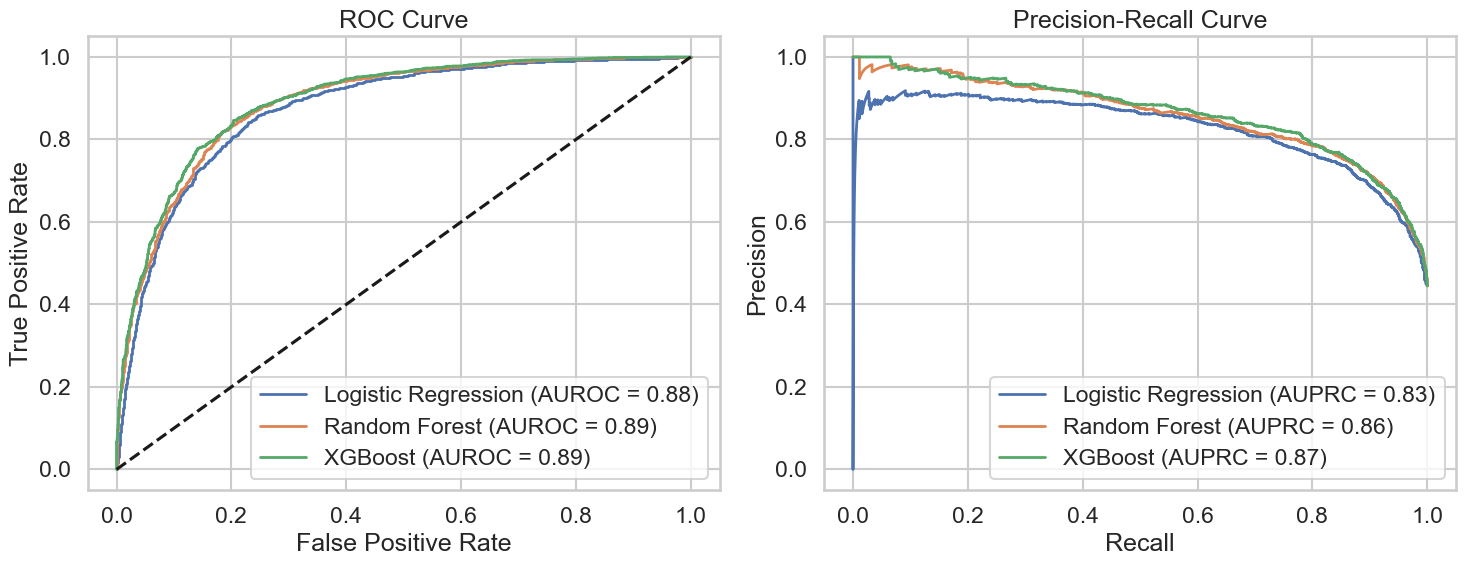

In [17]:
models = {
    'Logistic Regression': best_l1,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
    auroc = roc_auc_score(y_test, y_pred_proba)
    auprc = average_precision_score(y_test, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    ax[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUROC = {auroc:.2f})")
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    ax[1].plot(recall, precision, linewidth=2, label=f"{name} (AUPRC = {auprc:.2f})")
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()
plt.tight_layout()
plt.show()

### 3.2 Explainability (SHAP on XGBoost)

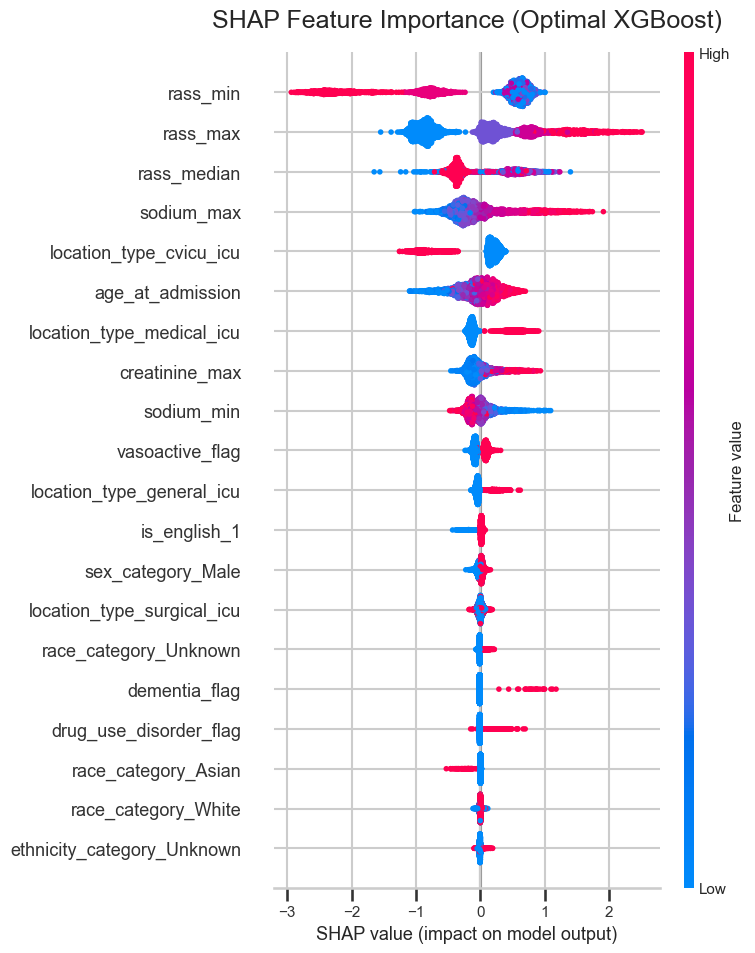

In [18]:
best_xgb = gs_xgb.best_estimator_
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test_df)

plt.figure(figsize=(10, 8), dpi=100)
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title('SHAP Feature Importance (Optimal XGBoost)', y=1.02)
plt.show()


## 4. Subsequent Analysis (ICU Length of Stay)

Evaluating independent predictors of Length of Stay via three methodologies: 
1. **Log-Transformed OLS:** Geometrical multiplicate mean shift.
2. **Negative Binomial:** Count-based Incidence Rate Ratio (IRR).
3. **Quantile Regression (q=0.5):** Robust, additive absolute shift on the central median.


In [19]:
print("Preparing subsequent analysis DataFrame...")
df_los = df.copy()
df_los = df_los[df_los['icu_hours'] > 0]
df_los['is_male'] = (df_los['sex_category'] == 'Male').astype(int)
df_los['is_english_1'] = df_los['is_english']
df_los['hx_stroke'] = df_los['hx_stroke'].fillna(0)
df_los['dementia_flag'] = df_los['dementia_flag'].fillna(0)
df_los['drug_use_disorder_flag'] = df_los['drug_use_disorder_flag'].fillna(0)
df_los['vasoactive_flag'] = df_los['vasoactive_flag'].fillna(0)
df_los['delirium_any'] = df_los['delirium_any'].fillna(0)

continuous_covariates = ['age_at_admission', 'rass_min', 'rass_max', 'creatinine_max', 'sodium_min', 'sodium_max']
for col in continuous_covariates:
    df_los[col] = df_los[col].fillna(df_los[col].median())
    df_los[col] = (df_los[col] - df_los[col].mean()) / df_los[col].std()

loc_dummies = pd.get_dummies(df_los['location_type'], drop_first=True, prefix='loc').astype(float)
df_los = pd.concat([df_los, loc_dummies], axis=1)

vars = ['is_english_1', 'is_male', 'hx_stroke', 'dementia_flag', 'drug_use_disorder_flag', 'delirium_any', 'vasoactive_flag'] + continuous_covariates + list(loc_dummies.columns)
X_los = df_los[vars]
X_los = sm.add_constant(X_los)
y_log = np.log(df_los['icu_hours'])
y_count = df_los['icu_hours'].apply(np.floor).astype(int)

Preparing subsequent analysis DataFrame...


### 4.1 OLS (Log-Linear)

In [20]:
ols_model = sm.OLS(y_log, X_los).fit(cov_type='HC3')
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              icu_hours   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     544.1
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:48:53   Log-Likelihood:                -17449.
No. Observations:               23947   AIC:                         3.493e+04
Df Residuals:                   23929   BIC:                         3.508e+04
Df Model:                          17                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      4

### 4.2 Negative Binomial (GLM)

In [21]:
nb_model = sm.GLM(y_count, X_los, family=sm.families.NegativeBinomial(alpha=1.0)).fit()
print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              icu_hours   No. Observations:                23947
Model:                            GLM   Df Residuals:                    23929
Model Family:        NegativeBinomial   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.3679e+05
Date:                Sun, 26 Apr 2026   Deviance:                       39703.
Time:                        23:49:10   Pearson chi2:                 7.32e+03
No. Iterations:                   100   Pseudo R-squ. (CS):             0.2086
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      4

### 4.3 Quantile Regression (Median q=0.5)
*Using a 10% sub-sample because QuantReg simplex optimizations run in O(N^3) standard form.*

In [22]:
sample_idx = df_los.sample(frac=0.1, random_state=42).index
quant_model = sm.QuantReg(y_count.loc[sample_idx], X_los.loc[sample_idx]).fit(q=0.5, max_iter=200)
print(quant_model.summary())

                         QuantReg Regression Results                          
Dep. Variable:              icu_hours   Pseudo R-squared:               0.1638
Model:                       QuantReg   Bandwidth:                       14.87
Method:                 Least Squares   Sparsity:                        87.82
Date:                Sun, 26 Apr 2026   No. Observations:                 2395
Time:                        23:49:22   Df Residuals:                     2377
                                        Df Model:                           17
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     93.8512      4.188     22.408      0.000      85.638     102.064
is_english_1               1.3075      3.160      0.414      0.679      -4.890       7.505
is_male                   -0.8006      1.859     -0.431      0.667      -4.447     